[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/NJK-25/biology-vs-math/blob/main/Biology-vs-Math-The-Final-Showdown.ipynb)

# Step 1: Initialization

In [2]:
!pip install yfinance pandas numpy matplotlib tabpfn scikit-learn

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tabpfn import TabPFNRegressor, TabPFNClassifier
import os

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 827.5/827.5 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 595.9/595.9 kB 37.3 MB/s eta 0:00:00


In [3]:
spy = yf.download("SPY", start="2015-01-01", end="2020-12-31", auto_adjust=True)
vix = yf.download("^VIX", start="2015-01-01", end="2020-12-31", auto_adjust=True)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


# Step 2: Data extraction and cleaning

In [ ]:
sp500 = yf.download("^GSPC", start="2014-11-01", end="2020-12-31", progress=False)
vix   = yf.download("^VIX",  start="2014-11-01", end="2020-12-31", progress=False)

# yfinance sometimes returns multi-level columns
if isinstance(sp500.columns, pd.MultiIndex):
    sp500.columns = sp500.columns.get_level_values(0)
if isinstance(vix.columns, pd.MultiIndex):
    vix.columns = vix.columns.get_level_values(0)

sp500 = sp500[["Close", "Volume"]].rename(columns={"Close": "sp_close", "Volume": "sp_volume"})
vix   = vix[["Close"]].rename(columns={"Close": "vix_close"})

df = sp500.join(vix, how="inner")

/tmp/ipykernel_469/771820929.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sp500 = yf.download("^GSPC", start="2014-11-01", end="2020-12-31", progress=False)
/tmp/ipykernel_469/771820929.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  vix   = yf.download("^VIX",  start="2014-11-01", end="2020-12-31", progress=False)


# Step 3: Feature Engineering

In [ ]:
# Everything is shifted so a day's features only use information known BEFORE that day
df["return"]    = df["sp_close"].pct_change()
df["ret_1"]     = df["return"].shift(1)                                          # yesterday's return
df["ma_5"]      = df["return"].rolling(5).mean().shift(1)                         # 5-day avg return
df["vol_10"]    = df["return"].rolling(10).std().shift(1)                         # 10-day volatility
df["volume_rel"] = (df["sp_volume"] / df["sp_volume"].rolling(10).mean()).shift(1) # relative volume
df["vix_yday"]    = df["vix_close"].shift(1)                                      # yesterday's VIX close

df["down_day"] = (df["return"] < 0).astype(int)

df = df.dropna()

features = ["ret_1", "ma_5", "vol_10", "volume_rel"]

# Step 4: Split into train (2015–2019) and test (2020) data

In [ ]:
# Train on 2015-2019, test through the 2020 crash
train = df.loc["2015-01-01":"2019-12-31"]
test  = df.loc["2020-01-01":"2020-12-31"].copy()

X_train, y_train = train[features].values, train["down_day"].values
X_test            = test[features].values

print("Training rows:", len(X_train), " | Test rows:", len(X_test))

Training rows: 1258  | Test rows: 252


# Step 5: Training the AI

In [ ]:
import os
os.environ["TABPFN_TOKEN"] = "<paste your key here>"

clf = TabPFNClassifier()
clf.fit(X_train, y_train)

test["ai_pred_down"] = clf.predict(X_test)
test["ai_prob_down"] = clf.predict_proba(X_test)[:, 1]

tabpfn-v3.5-20260909.safetensors: reconstructing file:   0%|          |  0.00B /  876MB            

tabpfn-v3.5-20260909.safetensors: downloading bytes:           |  0.00B            

config.json:   0%|          | 0.00/36.0 [00:00<?, ?B/s]

/usr/local/lib/python3.13/dist-packages/tabpfn/validation.py:234: UserWarning: Running on CPU with more than 1000 samples may be slow.
Consider using a GPU or the tabpfn-client API: https://github.com/PriorLabs/tabpfn-client
  _validate_num_samples_for_cpu(


# Step 6: The Simulation

In [ ]:
# AI: go to cash if the model predicts today will be a down day, else stay invested
test["ai_position"] = np.where(test["ai_prob_down"] > 0.47, 0, 1)

# Human: panic-sell everything the day after VIX closed above 35
test["human_position"] = np.where(test["vix_yday"] > 35, 0, 1)

#Simulate returns
test["buy_hold_return"]       = test["return"]
test["ai_strategy_return"]    = test["ai_position"] * test["return"]
test["human_strategy_return"] = test["human_position"] * test["return"]

cum = (1 + test[["buy_hold_return", "ai_strategy_return", "human_strategy_return"]]).cumprod()

# Step 7: Graphing the results

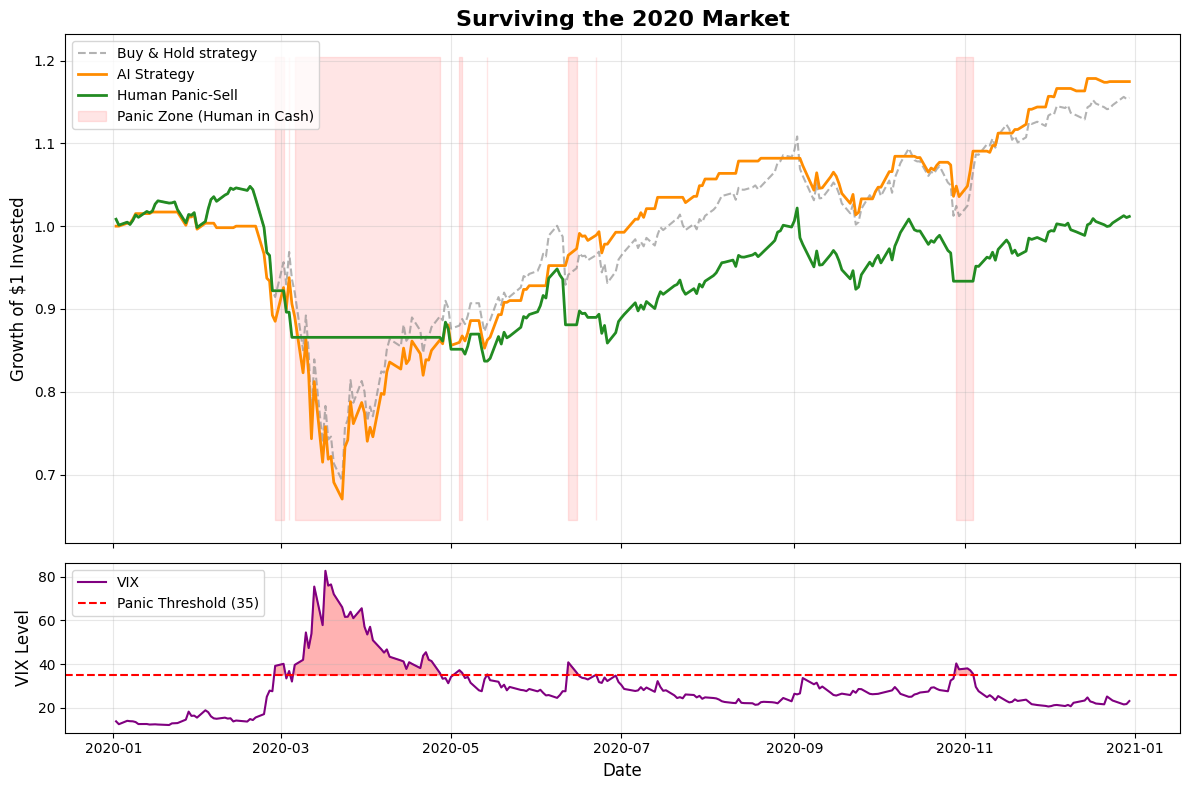

--- RESULTS FOR $1 INVESTED ---
Buy & Hold:  $1.16  (+15.52%)
AI:      $1.17  (+17.46%)
Human Panic: $1.01  (+1.17%)



In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

# TOP PANEL: The Equity Curves
ax1.plot(cum.index, cum["buy_hold_return"], label="Buy & Hold strategy", color='gray', linestyle='--', alpha=0.6, linewidth=1.5)
ax1.plot(cum.index, cum["ai_strategy_return"], label="AI Strategy", color='darkorange', linewidth=2)
ax1.plot(cum.index, cum["human_strategy_return"], label="Human Panic-Sell", color='forestgreen', linewidth=2)

ax1.fill_between(test.index, ax1.get_ylim()[0], ax1.get_ylim()[1],
                 where=(test["vix_yday"] > 35),
                 color='red', alpha=0.1, label="Panic Zone (Human in Cash)")

ax1.set_title("Surviving the 2020 Market", fontsize=16, fontweight='bold')
ax1.set_ylabel("Growth of $1 Invested", fontsize=12)
ax1.legend(loc="upper left", fontsize=10)
ax1.grid(alpha=0.3)

# BOTTOM PANEL: The VIX (Fear Index)
ax2.plot(test.index, test["vix_yday"], color='purple', linewidth=1.5, label="VIX")
ax2.axhline(35, color='red', linestyle='--', linewidth=1.5, label="Panic Threshold (35)")
ax2.fill_between(test.index, 35, test["vix_yday"],
                 where=(test["vix_yday"] > 35),
                 color='red', alpha=0.3)

ax2.set_ylabel("VIX Level", fontsize=12)
ax2.set_xlabel("Date", fontsize=12)
ax2.legend(loc="upper left", fontsize=10)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


final_multipliers = cum.iloc[-1]

final_percentages = (final_multipliers - 1) * 100

initial_investment = 10000
portfolio_values = final_multipliers * initial_investment

print("--- RESULTS FOR $1 INVESTED ---")
print(f"Buy & Hold:  ${final_multipliers['buy_hold_return']:.2f}  ({final_percentages['buy_hold_return']:+.2f}%)")
print(f"AI:      ${final_multipliers['ai_strategy_return']:.2f}  ({final_percentages['ai_strategy_return']:+.2f}%)")
print(f"Human Panic: ${final_multipliers['human_strategy_return']:.2f}  ({final_percentages['human_strategy_return']:+.2f}%)\n")


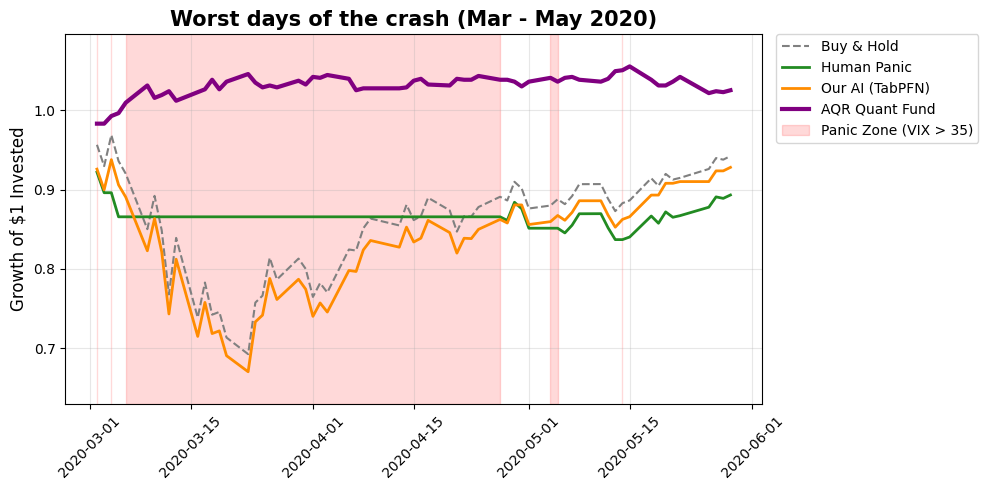

In [ ]:
# --- 15. The False Climax: Zoomed into the Crash (Mar - May 2020) ---
# Filter data strictly for the panic window and immediate recovery
crash_df = test.loc['2020-03-01':'2020-05-31']
crash_cum = cum.loc['2020-03-01':'2020-05-31']

fig, ax = plt.subplots(figsize=(10, 5))

# Plot everyone taking damage
ax.plot(crash_cum.index, crash_cum["buy_hold_return"], label="Buy & Hold", color='gray', linestyle='--', linewidth=1.5)
ax.plot(crash_cum.index, crash_cum["human_strategy_return"], label="Human Panic", color='forestgreen', linewidth=2)
ax.plot(crash_cum.index, crash_cum["ai_strategy_return"], label="Our AI (TabPFN)", color='darkorange', linewidth=2)

# Plot the institutional quant actually profiting from the chaos
ax.plot(crash_df.index, crash_df["cum_aqmix"], label="AQR Quant Fund", color='purple', linewidth=3)

# Shade the panic period dynamically where VIX > 35
ax.fill_between(crash_df.index, 0, 1,
                where=(crash_df["vix_yday"] > 35),
                color='red', alpha=0.15, transform=ax.get_xaxis_transform(),
                label="Panic Zone (VIX > 35)")

ax.set_title("Worst days of the crash (Mar - May 2020)", fontsize=15, fontweight='bold')
ax.set_ylabel("Growth of $1 Invested", fontsize=12)

# FIX: Move legend completely outside the plot to the right
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0., fontsize=10)

ax.grid(alpha=0.3)
plt.xticks(rotation=45)

# plt.tight_layout() will automatically adjust the margins to fit the new outside legend
plt.tight_layout()
plt.show()

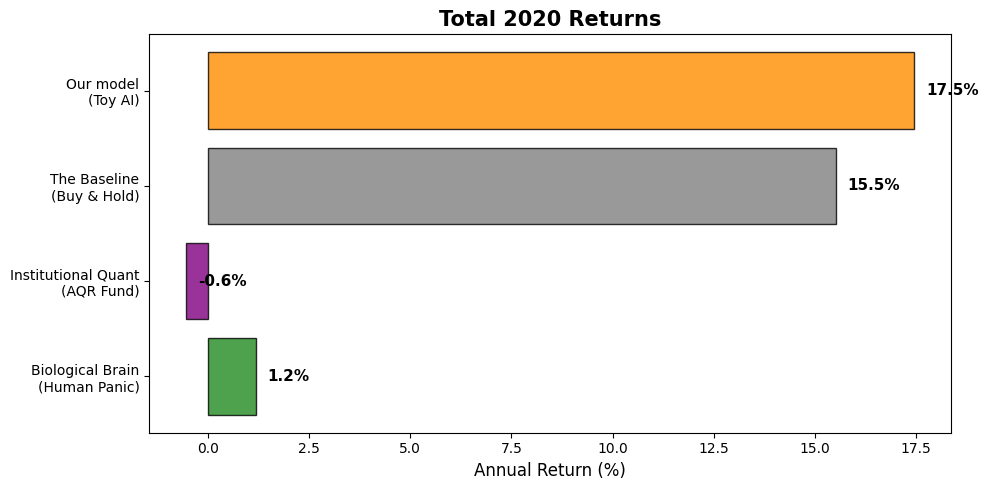

In [ ]:
# --- 16. The Reality Check: Final 2020 Returns Bar Chart ---
# Calculate the final percentage return for the entire year
final_human = (cum["human_strategy_return"].iloc[-1] - 1) * 100
final_aqr = (test["cum_aqmix"].iloc[-1] - 1) * 100
final_buy_hold = (cum["buy_hold_return"].iloc[-1] - 1) * 100
final_ai = (cum["ai_strategy_return"].iloc[-1] - 1) * 100

strategies = ['Biological Brain\n(Human Panic)', 'Institutional Quant\n(AQR Fund)', 'The Baseline\n(Buy & Hold)', 'Our model\n(Toy AI)']
returns = [final_human, final_aqr, final_buy_hold, final_ai]
colors = ['forestgreen', 'purple', 'gray', 'darkorange']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(strategies, returns, color=colors, edgecolor='black', alpha=0.8)

ax.set_title("Total 2020 Returns", fontsize=15, fontweight='bold')
ax.set_xlabel("Annual Return (%)", fontsize=12)

# Annotate the exact percentages directly onto the bars
for bar in bars:
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.1f}%', va='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()